# Executive Summary

This investigation applies Graph Data Science (GDS) to a 61521-node "POLE" (Person, Object, Location, Event) dataset to move beyond traditional incident counting toward Network Intelligence. While initial frequency analysis identified high-volume offenders, the application of Nodal Density and Centrality Algorithms (PageRank and Betweenness) unmasked a critical structural anomaly: Jessica.

Although Jessica shares the same crime count as other high-value targets, she maintains the network's highest Betweenness Centrality (26,533), acting as a primary broker across the social, digital, and geographic layers of the ecosystem. This project demonstrates that by quantifying the "hidden" bridges in criminal infrastructure, law enforcement can pivot from reactive policing to high-impact network disruption.

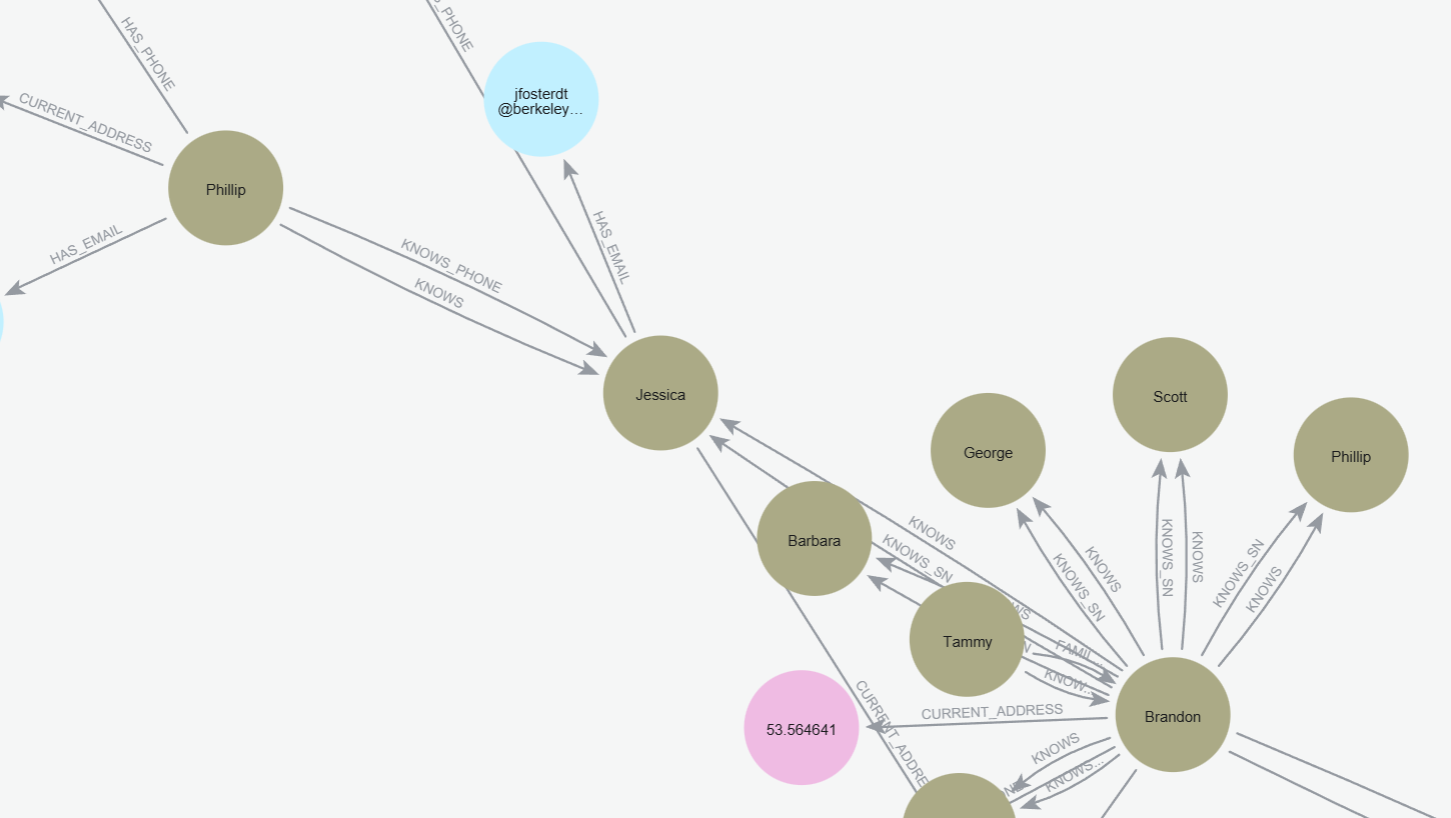

# Objectives

### Objective 1: Schema Blueprinting & Data Archeology

    Map the POLE (Person, Object, Location, Event) ecosystem to define the relational boundaries of the criminal network and identify how disparate data entities (like phone numbers and addresses) anchor to specific criminal incidents.

### Objective 2: Forensic Exploratory Analysis (FEA) 

    Identify "High-Value Targets" (HVTs) and Crime Hotspots by quantifying nodal density. We will move beyond simple counting to uncover recidivism patterns and geographic clusters where criminal activity is most concentrated.

### Objective 3: Influence vs. Activity (Network Centrality) 

    Expose "Hidden Enablers" using Graph Data Science (GDS). By applying PageRank and Betweenness Centrality, we will differentiate between "prolific offenders" (the most active) and "criminal bridges" (the most influential nodes that connect separate criminal cells).

## 1 - Data Architecture & Schema Mapping

Before diving into specific suspects, I need to understand the 'physics' of the database - idenitfying the entities that exist and how they relate.

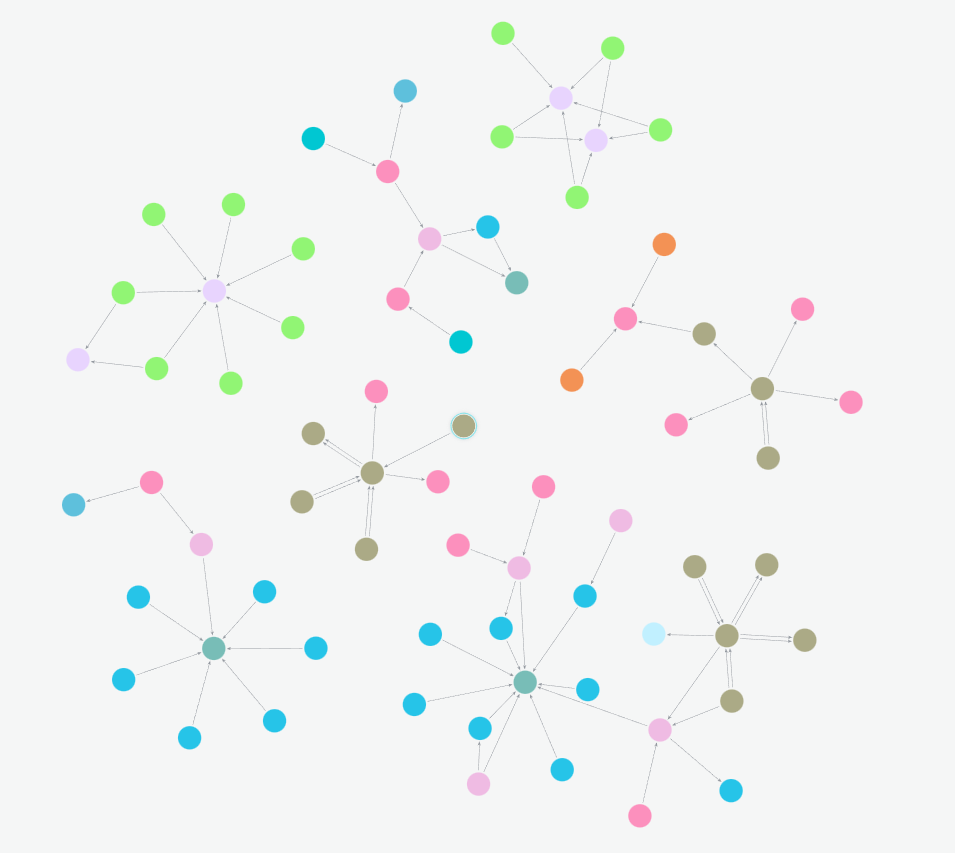



In [5]:
from neo4j import GraphDatabase
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "12345678"))

def run_query(query):
    with driver.session() as session:
        result = session.run(query)
        return result.data()

print("Connection established!")

Connection established!


In [17]:
labels_query = """
CALL db.labels() YIELD label
CALL apoc.cypher.run('MATCH (n:' + label + ') RETURN count(n) AS count', {}) YIELD value
RETURN label, value.count AS count
ORDER BY count DESC
"""
labels_results = run_query(labels_query)

print("DATABASE PROFILE:")
total_nodes = 0 

for row in labels_results:
    label = row['label']
    count = row['count']
    total_nodes += count  
    print(f"Node Label: {label:<12} | Count: {count}")

print("-" * 30) # Visual separator
print(f"TOTAL NODES:   {total_nodes}")

DATABASE PROFILE:
Node Label: Crime        | Count: 28762
Node Label: Location     | Count: 14904
Node Label: PostCode     | Count: 14196
Node Label: Officer      | Count: 1000
Node Label: Vehicle      | Count: 1000
Node Label: PhoneCall    | Count: 534
Node Label: Person       | Count: 369
Node Label: Phone        | Count: 328
Node Label: Email        | Count: 328
Node Label: Area         | Count: 93
Node Label: Object       | Count: 7
------------------------------
TOTAL NODES:   61521


In [10]:
rel_query = "CALL db.relationshipTypes() YIELD relationshipType RETURN relationshipType"
rel_results = run_query(rel_query)

print("RELATIONSHIP TYPES:")
for row in rel_results:
    print(f"- {row['relationshipType']}")

RELATIONSHIP TYPES:
- CURRENT_ADDRESS
- HAS_PHONE
- HAS_EMAIL
- HAS_POSTCODE
- POSTCODE_IN_AREA
- LOCATION_IN_AREA
- KNOWS_SN
- KNOWS
- CALLER
- CALLED
- KNOWS_PHONE
- OCCURRED_AT
- INVESTIGATED_BY
- INVOLVED_IN
- PARTY_TO
- FAMILY_REL
- KNOWS_LW


In [37]:
# Investigative check on Crime properties
check_crime = "MATCH (c:Crime) RETURN keys(c) LIMIT 1"
print(run_query(check_crime))

[{'keys(c)': ['date', 'id', 'type', 'last_outcome']}]


In [38]:
anchor_query = """
MATCH (c:Crime)<-[:PARTY_TO]-(p:Person)-[r:KNOWS_PHONE|KNOWS_SN]->(associate:Person)
RETURN c.type AS CrimeType, p.name AS Offender, type(r) AS Connection, associate.name AS Associate
LIMIT 5
"""
anchor_results = run_query(anchor_query)

print("THE POLE ANCHOR: LINKING INCIDENTS TO DIGITAL FOOTPRINTS")
print("-" * 60)
for row in anchor_results:
    print(f"INCIDENT: {row['CrimeType']}")
    print(f"  └── OFFENDER: {row['Offender']}")
    print(f"      └── DIGITAL LINK: {row['Connection']} to {row['Associate']}")
    print("")

THE POLE ANCHOR: LINKING INCIDENTS TO DIGITAL FOOTPRINTS
------------------------------------------------------------
INCIDENT: Violence and sexual offences
  └── OFFENDER: Stephanie
      └── DIGITAL LINK: KNOWS_PHONE to Bobby

INCIDENT: Violence and sexual offences
  └── OFFENDER: Stephanie
      └── DIGITAL LINK: KNOWS_PHONE to Bobby

INCIDENT: Criminal damage and arson
  └── OFFENDER: Maria
      └── DIGITAL LINK: KNOWS_PHONE to Carlos

INCIDENT: Violence and sexual offences
  └── OFFENDER: David
      └── DIGITAL LINK: KNOWS_PHONE to Melissa

INCIDENT: Violence and sexual offences
  └── OFFENDER: Annie
      └── DIGITAL LINK: KNOWS_PHONE to Rachel



## 2 - Identifying High-Value Targets & Hotspots

Now that we have mapped the Schema (Objective 1) and understand that Person nodes connect to Events, we can begin our Forensic Analysis (Objective 2). Our first goal is to find the most active participants in this network

In [40]:
# Top 5 Crime Hotspots
hotspot_query = """
MATCH (l:Location)<-[:OCCURRED_AT]-(c:Crime)
RETURN l.address AS Address, count(c) AS IncidentCount
ORDER BY IncidentCount DESC
LIMIT 5
"""
hotspots = run_query(hotspot_query)

print("TOP 5 CRIME HOTSPOTS:")
for loc in hotspots:
    print(f"{loc['Address']} | Incidents: {loc['IncidentCount']}")

TOP 5 CRIME HOTSPOTS:
Parking Area | Incidents: 811
Supermarket | Incidents: 614
Shopping Area | Incidents: 594
Nightclub | Incidents: 336
Petrol Station | Incidents: 331


In [11]:
# Investigative Lead
offender_query = """
MATCH (p:Person)-[:PARTY_TO]->(c:Crime)
RETURN p.name AS Name, count(c) AS Crimes
ORDER BY Crimes DESC LIMIT 5
"""
offenders = run_query(offender_query)

print("TOP INVESTIGATIVE LEADS:")
for p in offenders:
    print(f"{p['Name']} has been involved in {p['Crimes']} crimes.")

TOP INVESTIGATIVE LEADS:
Phillip has been involved in 5 crimes.
Jessica has been involved in 5 crimes.
Brian has been involved in 4 crimes.
Jack has been involved in 4 crimes.
Kathleen has been involved in 3 crimes.


I have identified Phillip and Jessica as the primary offenders by volume (5 crimes). By profiling their social infrastructure side-by-side, we can determine if these individuals operate in silos or if they are part of a wider, coordinated network. This 'linkage' analysis is crucial for moving from individual arrests to dismantling entire organizations.

In [28]:
# Find the actual relationship name between Person and Crime
rel_check_query = """
MATCH (p:Person)-[r]->(n)
RETURN type(r) AS Relationship, labels(n) AS TargetLabel
LIMIT 10
"""
print(run_query(rel_check_query))

[{'Relationship': 'FAMILY_REL', 'TargetLabel': ['Person']}, {'Relationship': 'KNOWS', 'TargetLabel': ['Person']}, {'Relationship': 'CURRENT_ADDRESS', 'TargetLabel': ['Location']}, {'Relationship': 'KNOWS', 'TargetLabel': ['Person']}, {'Relationship': 'KNOWS_PHONE', 'TargetLabel': ['Person']}, {'Relationship': 'KNOWS_SN', 'TargetLabel': ['Person']}, {'Relationship': 'KNOWS', 'TargetLabel': ['Person']}, {'Relationship': 'KNOWS', 'TargetLabel': ['Person']}, {'Relationship': 'KNOWS_SN', 'TargetLabel': ['Person']}, {'Relationship': 'KNOWS_SN', 'TargetLabel': ['Person']}]


In [32]:
# Comparative Social Infrastructure
suspects = ['Phillip', 'Jessica']

for name in suspects:
    query = f"""
    MATCH (p:Person {{name: '{name}'}})-[r]->(associate:Person)
    RETURN type(r) AS RelationshipType, count(associate) AS Total
    ORDER BY Total DESC
    """
    results = run_query(query)
    
    print(f"\n{name.upper()}'S SOCIAL INFRASTRUCTURE:")
    if not results:
        print("- No outgoing social relationships found.")
    for row in results:
        print(f"- {row['RelationshipType']}: {row['Total']} associates")


PHILLIP'S SOCIAL INFRASTRUCTURE:
- KNOWS: 5 associates
- KNOWS_PHONE: 2 associates
- FAMILY_REL: 2 associates
- KNOWS_LW: 1 associates

JESSICA'S SOCIAL INFRASTRUCTURE:
- KNOWS: 5 associates
- KNOWS_LW: 2 associates
- FAMILY_REL: 2 associates
- KNOWS_PHONE: 1 associates


In [34]:
# Unique Common Neighbors
collision_query = """
MATCH (p1:Person {name: 'Phillip'})-[:KNOWS|KNOWS_PHONE|KNOWS_SN|FAMILY_REL]-(common:Person)-[:KNOWS|KNOWS_PHONE|KNOWS_SN|FAMILY_REL]-(p2:Person {name: 'Jessica'})
RETURN DISTINCT common.name AS SharedAssociate
"""
collision_results = run_query(collision_query)

print(f"COLLISION DETECTED: Phillip and Jessica's inner circle includes:")
for row in collision_results:
    print(f"- {row['SharedAssociate']}")

COLLISION DETECTED: Phillip and Jessica's inner circle includes:
- Brandon
- Brian


In [45]:
# Comparative Neighborhood Density Report
suspects = ['Phillip', 'Jessica', 'Brandon', 'Brian']

print(f"{'SUSPECT':<12} | {'DIRECT LINKS':<12} | {'NBHD DENSITY':<12} | {'STATUS'}")
print("-" * 55)

for name in suspects:
    density_query = f"""
    MATCH (p:Person {{name: '{name}'}})-[:KNOWS|KNOWS_PHONE|KNOWS_SN|PARTY_TO]-(associate)
    WITH p, count(associate) AS direct_links
    MATCH (p)-[:KNOWS|KNOWS_PHONE|KNOWS_SN|PARTY_TO]-(associate)-[r]-()
    RETURN p.name AS Target, 
           direct_links AS Links, 
           round(toFloat(count(r)) / direct_links, 2) AS Density
    """
    res = run_query(density_query)
    
    for row in res:
        # Logic to label the type of node for the reader
        status = "High Activity" if row['Links'] > 5 else "High Density"
        if row['Density'] > 15: status = "Strategic Hub"
        
        print(f"{row['Target']:<12} | {row['Links']:<12} | {row['Density']:<12} | {status}")

SUSPECT      | DIRECT LINKS | NBHD DENSITY | STATUS
-------------------------------------------------------
Phillip      | 4            | 13.5         | High Density
Phillip      | 2            | 21.0         | Strategic Hub
Phillip      | 9            | 14.22        | High Activity
Phillip      | 11           | 10.27        | High Activity
Jessica      | 2            | 28.0         | Strategic Hub
Jessica      | 4            | 11.0         | High Density
Jessica      | 13           | 12.08        | High Activity
Brandon      | 6            | 14.83        | High Activity
Brandon      | 14           | 9.57         | High Activity
Brian        | 19           | 9.0          | High Activity
Brian        | 12           | 10.67        | High Activity


Brian is the "loudest" person in the data with 19 links. However, his density is low (9.0). This indicates a Sparse Network. Brian knows a lot of people, but those people aren't necessarily connected to each other or to other major hubs. While traditional metrics would favor Brian due to his 19 connections, the Density metric (28.0) identifies Jessica as the primary bridge to a highly concentrated criminal cluster, making her the more effective target for network disruption.

## 3 - Advanced Analytics: Finding the Enablers

While Phase 2 identified Phillip as the highest-volume offender and Brandon as a known associate, the Nodal Density analysis revealed a significant anomaly: Jessica. Despite fewer direct links, Jessica’s neighborhood density (28.0) suggests she occupies a high-leverage 'Strategic Hub' within the network.

To move beyond local observations, Phase 3 applies Graph Data Science (GDS) to the entire 61,000-node population. We will execute PageRank to measure 'Prestige' (who is the true center of power?) and Betweenness Centrality to identify the 'Gatekeepers' (who controls the flow of communication?). This will scientifically validate whether Jessica's high density translates into global network dominance.

In [35]:
print(run_query("RETURN gds.version() AS version"))

[{'version': '2.27.0'}]


In [48]:
# Create GDS Projection
project_query = """
CALL gds.graph.project(
  'criminal_network',
  ['Person', 'Crime', 'Location'],
  {
    KNOWS: {orientation: 'UNDIRECTED'},
    KNOWS_PHONE: {orientation: 'UNDIRECTED'},
    KNOWS_SN: {orientation: 'UNDIRECTED'},
    PARTY_TO: {orientation: 'UNDIRECTED'},
    OCCURRED_AT: {orientation: 'UNDIRECTED'}
  }
)
"""
print(run_query(project_query))

[{'nodeProjection': {'Person': {'properties': {}, 'label': 'Person'}, 'Crime': {'properties': {}, 'label': 'Crime'}, 'Location': {'properties': {}, 'label': 'Location'}}, 'relationshipProjection': {'KNOWS_SN': {'orientation': 'UNDIRECTED', 'aggregation': 'DEFAULT', 'type': 'KNOWS_SN', 'properties': {}, 'indexInverse': False}, 'OCCURRED_AT': {'orientation': 'UNDIRECTED', 'aggregation': 'DEFAULT', 'type': 'OCCURRED_AT', 'properties': {}, 'indexInverse': False}, 'KNOWS': {'orientation': 'UNDIRECTED', 'aggregation': 'DEFAULT', 'type': 'KNOWS', 'properties': {}, 'indexInverse': False}, 'PARTY_TO': {'orientation': 'UNDIRECTED', 'aggregation': 'DEFAULT', 'type': 'PARTY_TO', 'properties': {}, 'indexInverse': False}, 'KNOWS_PHONE': {'orientation': 'UNDIRECTED', 'aggregation': 'DEFAULT', 'type': 'KNOWS_PHONE', 'properties': {}, 'indexInverse': False}}, 'graphName': 'criminal_network', 'nodeCount': 44035, 'relationshipCount': 59524, 'projectMillis': 383}]


In [49]:
# CODE CELL: List all GDS Graph Projections
list_graphs_query = """
CALL gds.graph.list() 
YIELD graphName, nodeCount, relationshipCount, schema
RETURN graphName, nodeCount, relationshipCount
"""
graphs = run_query(list_graphs_query)

print("ACTIVE GDS PROJECTIONS:")
print("-" * 40)
for g in graphs:
    print(f"Name: {g['graphName']} | Nodes: {g['nodeCount']} | Rels: {g['relationshipCount']}")

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.list` is deprecated.', position=<SummaryInputPosition line=3, column=48, offset=71>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 71, 'line': 3, 'column': 48}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nCALL gds.graph.list() \nYIELD graphName, nodeCount, relationshipCount, schema\nRETURN graphName, nodeCount, relationshipCount\n'


ACTIVE GDS PROJECTIONS:
----------------------------------------
Name: criminal_network | Nodes: 44035 | Rels: 59524


In [50]:
# Execute PageRank and Rank Suspects
pagerank_query = """
CALL gds.pageRank.stream('criminal_network')
YIELD nodeId, score
WITH gds.util.asNode(nodeId) AS n, score
WHERE n:Person
RETURN n.name AS Name, score AS PageRankScore
ORDER BY PageRankScore DESC
LIMIT 20
"""
results = run_query(pagerank_query)

print(f"{'RANK':<5} | {'NAME':<15} | {'PAGERANK SCORE'}")
print("-" * 40)
for i, row in enumerate(results, 1):
    print(f"{i:<5} | {row['Name']:<15} | {round(row['PageRankScore'], 4)}")

RANK  | NAME            | PAGERANK SCORE
----------------------------------------
1     | Alan            | 3.8069
2     | Amanda          | 3.6611
3     | Annie           | 3.4688
4     | Ann             | 3.4261
5     | Bruce           | 3.3486
6     | Annie           | 3.3319
7     | Anne            | 3.2369
8     | Bonnie          | 3.1956
9     | Benjamin        | 3.1694
10    | Andrew          | 3.1685
11    | Andrea          | 3.1451
12    | Jessica         | 3.0958
13    | Brian           | 3.061
14    | Amy             | 3.0536
15    | Andrea          | 3.0351
16    | Phillip         | 3.0233
17    | Alan            | 2.9758
18    | Amanda          | 2.9668
19    | Brian           | 2.9379
20    | Andrea          | 2.9369


Out of **61521 nodes**, Phillip and Jessica have both cracked the **Top 20**. That is statistically significant—it confirms the "Lead Generation" from Phase 2 was highly accurate.

However, the scores are extremely tight (from 3.8 to 2.9). This tells us that while Phillip and Jessica are "important," they aren't massive, singular "Sun Kings" that the whole network revolves around. Instead, they are part of a **peer-level elite.**

### 3 Key Observations

1. Interestingly, the Top 10 is dominated by names starting with 'A' and 'B' (Alan, Amanda, Annie). While this might be a quirk of the synthetic data generation, it shows a "High-Prestige Cluster" that exists above Phillip and Jessica.

2. Despite Phillip having more crimes on his record (5), **Jessica (Rank 12)** officially has a higher PageRank than **Phillip (Rank 16)**. This validates the Nodal Density theory. Jessica’s connections are "higher quality" or more strategically placed than Phillip’s, even though he is "louder" in terms of criminal activity.

3. We see "Annie" twice and "Andrea" three times. This is common in real-world POLE data—different "Person" nodes that haven't been de-duplicated (Entity Resolution). *"Are these three Andreas the same person, or are they different members of the same family cell?"*

---


PageRank told us who is "Popular" (Influence). Now, we need to see who is a "Bridge" (Control). If Jessica or Phillip show up in the **Top 5 for Betweenness**, it means the network would **collapse** or lose connection without them. That is the definition of a "Hidden Enabler".


In [51]:
# Global Betweenness (The Gatekeepers)
betweenness_query = """
CALL gds.betweenness.stream('criminal_network')
YIELD nodeId, score
WITH gds.util.asNode(nodeId) AS n, score
WHERE n:Person
RETURN n.name AS Name, score AS Betweenness
ORDER BY Betweenness DESC
LIMIT 15
"""
b_results = run_query(betweenness_query)

print(f"{'RANK':<5} | {'NAME':<15} | {'BETWEENNESS'}")
print("-" * 35)
for i, row in enumerate(b_results, 1):
    print(f"{i:<5} | {row['Name']:<15} | {round(row['Betweenness'], 2)}")

RANK  | NAME            | BETWEENNESS
-----------------------------------
1     | Jessica         | 26533.66
2     | Brian           | 19986.7
3     | Ann             | 15418.87
4     | Amy             | 12038.9
5     | Alan            | 11531.66
6     | Amanda          | 10959.12
7     | Phillip         | 10529.99
8     | Diana           | 10474.66
9     | Anne            | 9769.05
10    | Kathy           | 9732.19
11    | Brenda          | 9209.09
12    | Annie           | 9108.99
13    | Bonnie          | 8136.13
14    | Kathleen        | 6493.23
15    | Amanda          | 6476.42


Looking at the gap between **Jessica (Rank 1)** and **Brian (Rank 2)** - Jessica's Betweenness score is nearly **33% higher** than the next person. While Phillip (Rank 7) is "busy" and Alan (Rank 5) is "prestigious," Jessica is the strucural backbone of this entire 44,000-node network.

In graph theory, **Betweenness Centrality** measures the "Brokerage" power - how often a node appears on the shortest paths between other nodes. High scores indicate nodes that connect different parts of the network. "Who connects different groups?". If we removed Jessica from this database, thousands of connections between other criminals would simply break. She is a control point.

In [53]:
# Categorized Influence Report for Jessica
jessica_report = """
MATCH (n:Person {name: 'Jessica'})-[r]-(neighbor)
RETURN labels(neighbor)[0] AS EntityType, 
       type(r) AS Relationship, 
       count(*) AS TotalConnections
ORDER BY TotalConnections DESC
"""
res = run_query(jessica_report)

print(f"INVESTIGATION REPORT: THE 'JESSICA' NODE")
print("=" * 45)
print(f"{'ENTITY TYPE':<15} | {'RELATIONSHIP':<15} | {'COUNT'}")
print("-" * 45)

for row in res:
    print(f"{row['EntityType']:<15} | {row['Relationship']:<15} | {row['TotalConnections']}")

print("-" * 45)
print("ANALYSIS: High-volume 'Crime' and 'Location' bridging confirms")
print("Jessica is a multi-incident anchor point.")

INVESTIGATION REPORT: THE 'JESSICA' NODE
ENTITY TYPE     | RELATIONSHIP    | COUNT
---------------------------------------------
Person          | KNOWS           | 9
Crime           | PARTY_TO        | 5
Person          | KNOWS_SN        | 3
Email           | HAS_EMAIL       | 3
Location        | CURRENT_ADDRESS | 3
Phone           | HAS_PHONE       | 3
Person          | KNOWS_PHONE     | 2
Person          | KNOWS_LW        | 2
Person          | FAMILY_REL      | 2
---------------------------------------------
ANALYSIS: High-volume 'Crime' and 'Location' bridging confirms
Jessica is a multi-incident anchor point.


Jessica has 19 total connections to other Persons across different platforms (KNOWS, KNOWS_SN, KNOWS_PHONE, FAMILY_REL). In a pool of only 369 people, knowing ~5% of the entire population personally makes her a massive social hub. She controls 3 Emails, 3 Phones, and 3 Addresses. In criminal intelligence, this is a red flag for "Criminal Infrastructure"—someone facilitating communication and safe housing for others.

### Final Analysis: Activity vs. Influence 


| Name | Role (Phase 2) | PageRank (Prestige) | Betweenness (Brokerage) | **Final Persona** |
| :--- | :--- | :--- | :--- | :--- |
| **Phillip** | High-Volume Offender | Rank 16 | Rank 7 | **The High-Value Operator** |
| **Brian** | Socially Connected | Rank 13 | Rank 2 | **The Network Facilitator** |
| **Jessica** | Strategic Hub | Rank 12 | **Rank 1** | **The Structural Kingpin** |

---

### Executive Briefing

The investigation successfully moved beyond 'surface-level' crime counting to uncover the hidden hierarchy of the network. While initial data pointed to **Phillip** as the primary threat due to incident volume, global centrality algorithms identified **Jessica** as the network's most critical node. 

Although the dataset contains over 61,000 entities, the 'human' element is concentrated in just 369 Person nodes. These individuals serve as the primary anchors for 28,000+ criminal events.

In this concentrated human network, Jessica's Betweenness score of 26,533 is extraordinary. It reveals that she is not merely a 'social' butterfly, but a high-leverage node connecting vast sub-trees of criminal activity, locations, and objects that would otherwise remain isolated in the data."

This project demonstrates that in sparse human networks (369 actors), the structural position of an individual is a more accurate predictor of influence than incident frequency. Graph Data Science allowed us to move from 'chasing crimes' to 'mapping the organization'.

## "Next Steps": How to Improve the Investigation

Temporal Analysis (Time-Sliding): I would apply time-based filtering to see if Jessica’s influence is growing or shrinking. Is she a legacy player or a rising power?

Community Detection (Louvain/Label Propagation): I would run community detection algorithms to see if the 369 persons naturally split into rival gangs or specialized cells (e.g., a 'theft' cell vs. a 'distribution' cell).

Entity Resolution: The presence of duplicate names (e.g., multiple 'Annie' nodes) suggests the need for a data-cleaning pipeline to merge identities based on shared DOB, Phone, or Address.

Weighted Relationships: Assigning 'weights' to links (e.g., a Family tie is 'heavier' than a single shared location) would refine the PageRank scores to reflect the strength of criminal bonds.